In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                if neighbor not in visited and random.random() <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
if not os.path.exists(f"fig_data/fig05/fig05.pkl"):
    result = defaultdict(lambda: defaultdict(list))
    real_path = f"data/real_networks.pkl"
    real_graphs = load_graphs(real_path)
    print(f"Running simulation for real network:")
    for graph in tqdm(real_graphs.values()):
        graph_result = run_simulation_by_k(graph)
        for k, metrics in graph_result.items():
            for metric, values in metrics.items():
                result[k][metric].extend(values)
    result = to_dict(result)
    del real_graphs
    with open(f"fig_data/fig05/fig05.pkl", "wb") as f:
        pickle.dump(result, f)
    del result

Running simulation for real network:


100%|██████████| 84/84 [00:02<00:00, 33.63it/s]


Fig 5a
A: 4.0379685023127125, B: -2.254296369659339


C:\Users\HP\AppData\Local\Temp\ipykernel_23176\3526039111.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


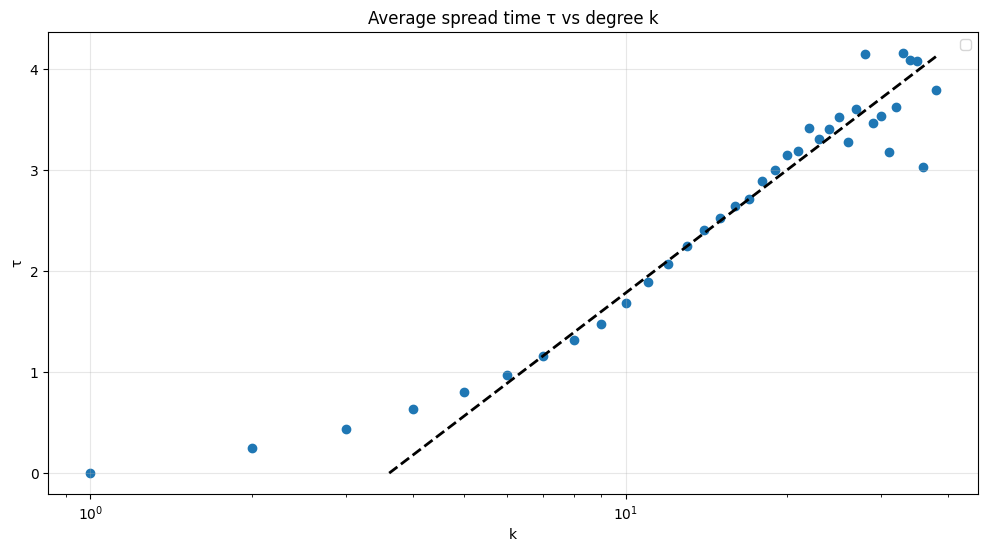

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#Spread time
plt.figure(figsize=(12, 6))
real_data_by_k = load_graphs(f"fig_data/fig05/fig05.pkl")
real_plot_data_by_k = defaultdict(dict)
for k in real_data_by_k:
    real_plot_data_by_k[k]["spread_time"] = sum(real_data_by_k[k]["spread_time"]) / len(real_data_by_k[k]["spread_time"])
ks = np.array(sorted(real_plot_data_by_k))
spread_times = np.array([real_plot_data_by_k[k]["spread_time"] for k in ks])

plt.scatter(ks, spread_times)

# Fit the later half of k values
start = len(ks) // 6
end = 7 *len(ks) // 8
x_fit = np.log10(ks[start:end])
y_fit = spread_times[start:end]
a, b = np.polyfit(x_fit, y_fit, 1)
x_line = np.logspace(-b / a, np.log10(ks[-1]), 200)
y_line = a * np.log10(x_line) + b

plt.plot(
    x_line,
    y_line,
    "k--",
    linewidth=2
)
del real_data_by_k, real_plot_data_by_k

print("Fig 5a")
print(f"A: {a}, B: {b}")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

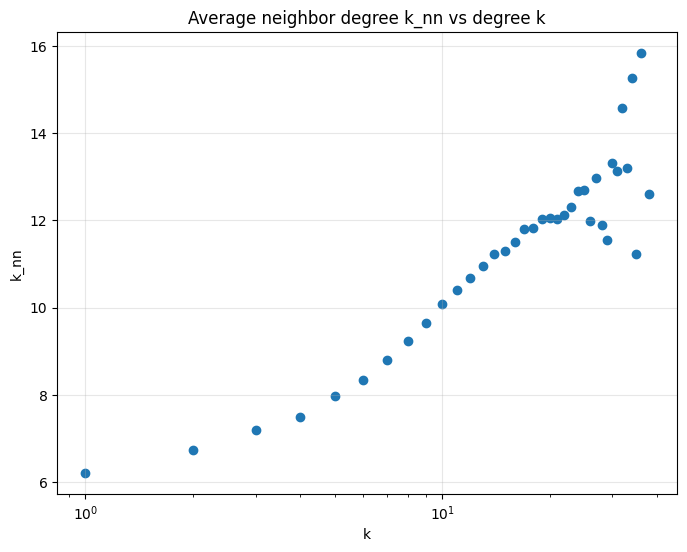

In [5]:
knn = defaultdict(list)
real_path = f"data/real_networks.pkl"
real_graphs = load_graphs(real_path)
for real_graph in real_graphs.values():
    for node, neighbors in real_graph.items():
        for neighbor in neighbors:
            knn[len(neighbors)].append(len(real_graph[neighbor]))

for k,v in knn.items():
    knn[k] = sum(v) / len(v)

plt.figure(figsize=(8, 6))
plt.scatter(list(knn.keys()), list(knn.values()))
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("k_nn")
plt.title("Average neighbor degree k_nn vs degree k")
plt.grid(True, alpha=0.3)
plt.show()

Fig 5b


C:\Users\HP\AppData\Local\Temp\ipykernel_23176\3682028735.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


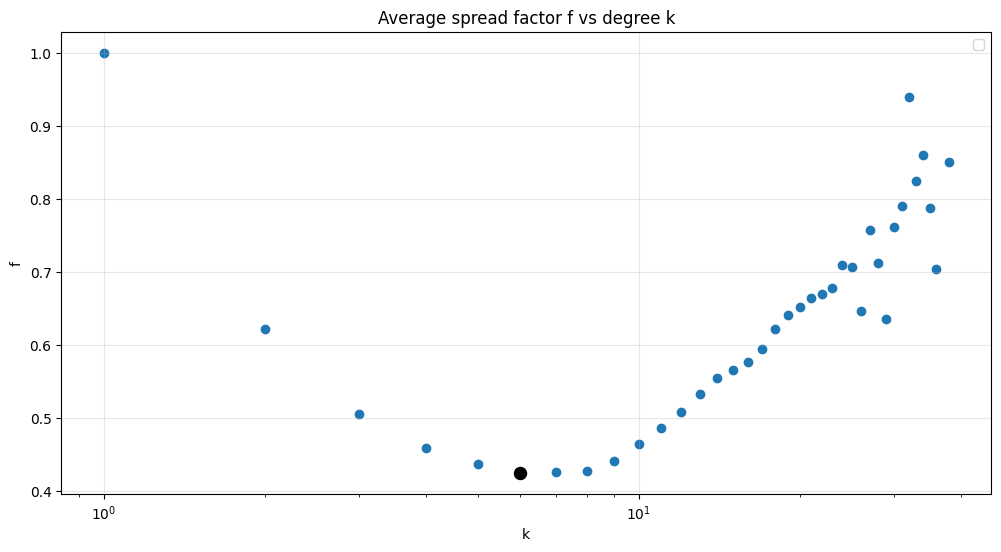

In [6]:
#Spread factor
plt.figure(figsize=(12, 6))
real_data_by_k = load_graphs(f"fig_data/fig05/fig05.pkl")
real_plot_data_by_k = defaultdict(dict) 
for k in real_data_by_k: 
    real_plot_data_by_k[k]["spread_factor"] = sum(real_data_by_k[k]["spread_factor"]) / len(real_data_by_k[k]["spread_factor"])
ks = sorted(real_plot_data_by_k)
spread_factors = [real_plot_data_by_k[k]["spread_factor"]for k in ks]

#k0
idx = spread_factors.index(min(spread_factors))
plt.scatter(
    ks[idx],
    spread_factors[idx],
    s=75,
    color="black",
    zorder=10
)

plt.scatter(ks, spread_factors)
del real_data_by_k, real_plot_data_by_k

print("Fig 5b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("f")
plt.title("Average spread factor f vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 5b inset


C:\Users\HP\AppData\Local\Temp\ipykernel_23176\2540623018.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


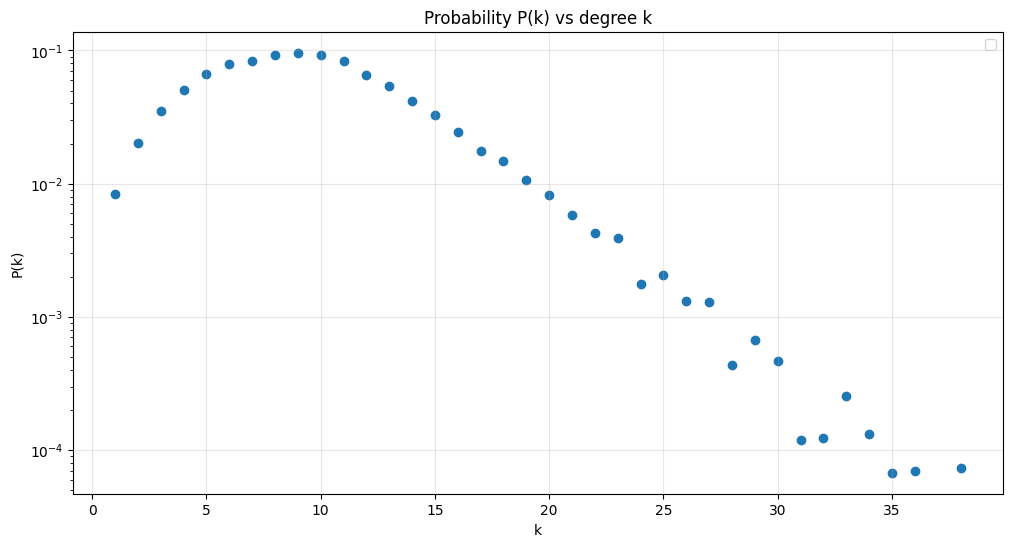

In [10]:
#Distribution of k
plt.figure(figsize=(12, 6))
real_data_by_k = load_graphs(f"fig_data/fig05/fig05.pkl")
real_plot_data_by_k = defaultdict(dict) 
for k in real_data_by_k: 
    real_plot_data_by_k[k]["count"] = len(real_data_by_k[k]["spread_factor"])
ks = sorted(real_plot_data_by_k)
count = [real_plot_data_by_k[k]["count"]for k in ks]
total_count = sum(count)
normalized_count = [c / total_count for c in count]

plt.scatter(ks, normalized_count)
del real_data_by_k, real_plot_data_by_k

print("Fig 5b inset")
plt.yscale("log")
plt.xlabel("k")
plt.ylabel("P(k)")
plt.title("Probability P(k) vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()